In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

In [13]:
df = pd.read_csv("physical_activity.csv")
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Actvitiy,Description
0,Bicycling,"Bicycling, mountain, competitive racing"
1,Bicycling,"Bicycling, BMX"
2,Bicycling,"Bicycling, mountain, general"
3,Bicycling,"Bicycling, <10 mph, leisure, to work or for pl..."
4,Bicycling,"Bicycling, to/from work, self selected pace"


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Actvitiy     1125 non-null   object
 1   Description  1125 non-null   object
dtypes: object(2)
memory usage: 17.7+ KB


In [15]:
df.shape

(1125, 2)

In [16]:
def remove_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filter the DataFrame
    return df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

In [18]:
df['text'] = df['Actvitiy'] + " " + df['Description']

In [20]:
df_clean = remove_outliers(df)
print(f"Original size: {len(df)}, Cleaned size: {len(df_clean)}")

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(scaled_data)

In [8]:
fig = px.scatter_3d(
    df_clean, 
    x='Feature_A', 
    y='Feature_B', 
    z='Feature_C',
    color='Cluster',
    title="Interactive 3D Cluster Plot",
    opacity=0.8,
    # template="plotly_dark"
)
fig.show()

In [9]:
score = silhouette_score(scaled_data, df_clean['Cluster'])
print(f"Average Silhouette Score: {score:.3f}")

Average Silhouette Score: 0.272


In [10]:
# Visualizing Silhouette Plot
sample_silhouette_values = silhouette_samples(scaled_data, df_clean['Cluster'])

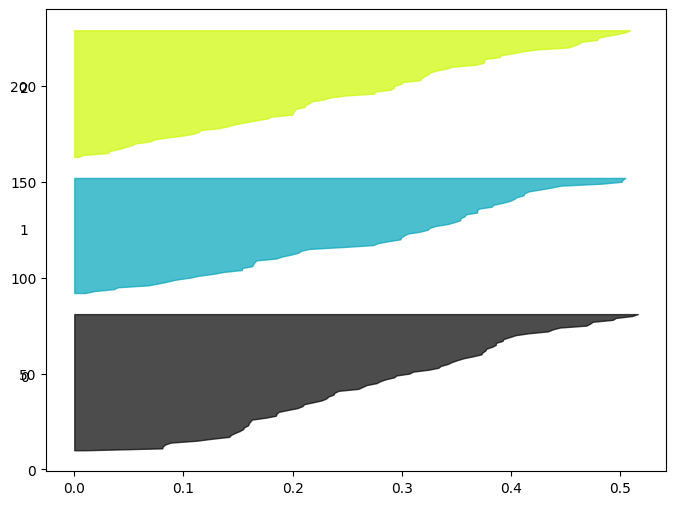

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
y_lower = 10
for i in range(3): # For each cluster
    ith_cluster_silhouette_values = sample_silhouette_values[df_clean['Cluster'] == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i) / 3)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                    facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

In [12]:
ax1.set_title("Silhouette Plot for Various Clusters")
ax1.set_xlabel("Silhouette Coefficient Values")
ax1.set_ylabel("Cluster Label")
ax1.axvline(x=score, color="red", linestyle="--") # Average score line
plt.show()